In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('/content/data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(150444, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150444 entries, 0 to 150443
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    150444 non-null  object 
 1   StockCode    150444 non-null  object 
 2   Description  149846 non-null  object 
 3   Quantity     150444 non-null  int64  
 4   InvoiceDate  150443 non-null  object 
 5   UnitPrice    150443 non-null  float64
 6   CustomerID   103940 non-null  float64
 7   Country      150443 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 9.2+ MB
None
InvoiceNo          0
StockCode          0
Description      598
Quantity           0
InvoiceDate        1
UnitPrice          1
CustomerID     46504
Country            1
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

df = df.dropna(subset=['CustomerID'])

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,81,1,77183.60
1,12347.0,2,3,1823.43
2,12348.0,4,3,1487.24
3,12350.0,65,1,334.40
4,12352.0,17,5,1561.81


In [ ]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,2232.000000,2232.000000,2232.000000
mean,47.974462,2.255376,1036.006855
std,38.875876,3.071568,3443.953608
min,1.000000,1.000000,0.850000
25%,16.000000,1.000000,222.562500
50%,38.000000,1.000000,408.030000
75%,73.000000,2.000000,897.447500
max,129.000000,58.000000,81612.620000


In [ ]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

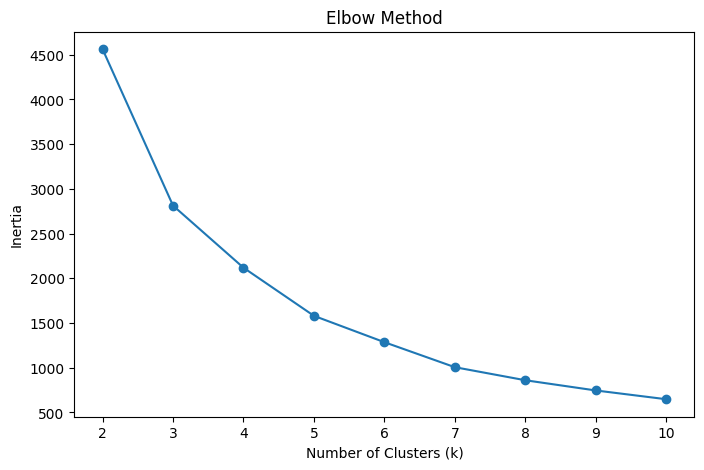

In [ ]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

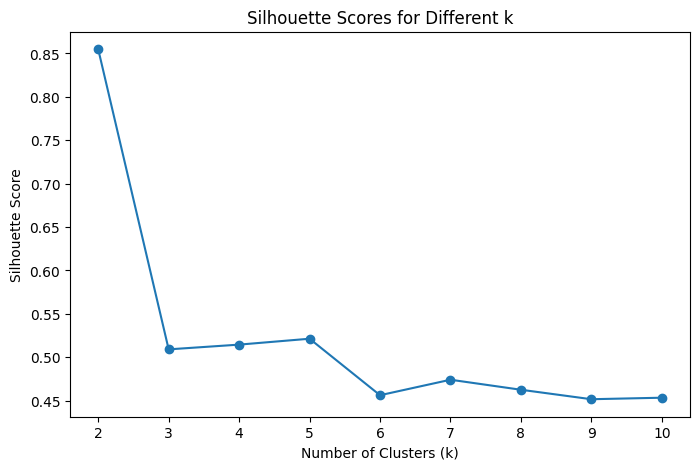

[np.float64(0.8549090446726628), np.float64(0.5091228932577542), np.float64(0.514585513711414), np.float64(0.521381099427365), np.float64(0.45628540309991655), np.float64(0.4741394622932777), np.float64(0.46259097562552076), np.float64(0.45167986950859396), np.float64(0.4534259167260782)]


In [ ]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.show()

print(scores)

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,81,1,77183.60,3
1,12347.0,2,3,1823.43,0
2,12348.0,4,3,1487.24,0
3,12350.0,65,1,334.40,2
4,12352.0,17,5,1561.81,0


In [ ]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0          24.13       2.40    927.43
1          11.46      23.38  13100.21
2          95.23       1.25    451.58
3          21.00       8.67  52347.27


In [ ]:
print(rfm['Cluster'].value_counts())

Cluster
0    1449
2     753
1      24
3       6
Name: count, dtype: int64


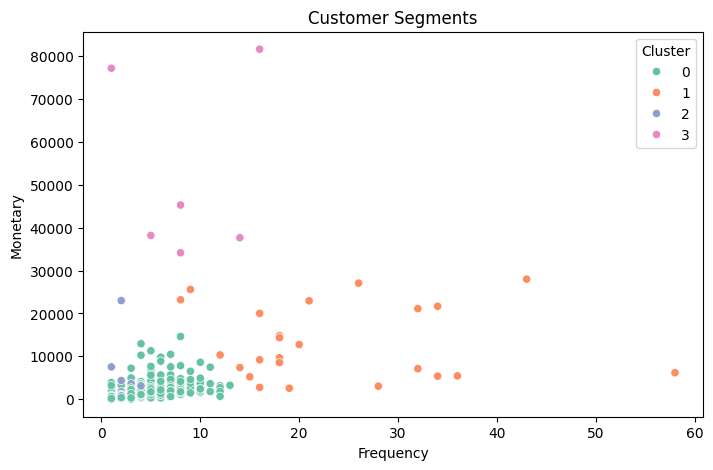

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Customer Segments')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# warnings off
import warnings
warnings.filterwarnings('ignore')

# plot style
sns.set_style("whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('data.csv', encoding='latin1')
df.head()

Saving data.csv to data (1).csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
# Make a copy
data = df.copy()

# Remove duplicate rows
data.drop_duplicates(inplace=True)

# Remove rows where CustomerID is missing
data = data.dropna(subset=['CustomerID'])

# Keep only positive quantity and positive price
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Create TotalPrice column
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

print("Cleaned data shape:", data.shape)
display(data.head())

Cleaned data shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
print(data.describe(include='all'))

       InvoiceNo StockCode                         Description       Quantity  \
count     392692    392692                              392692  392692.000000   
unique     18532      3665                                3877            NaN   
top       576339    85123A  WHITE HANGING HEART T-LIGHT HOLDER            NaN   
freq         542      2023                                2016            NaN   
mean         NaN       NaN                                 NaN      13.119702   
min          NaN       NaN                                 NaN       1.000000   
25%          NaN       NaN                                 NaN       2.000000   
50%          NaN       NaN                                 NaN       6.000000   
75%          NaN       NaN                                 NaN      12.000000   
max          NaN       NaN                                 NaN   80995.000000   
std          NaN       NaN                                 NaN     180.492832   

                          I

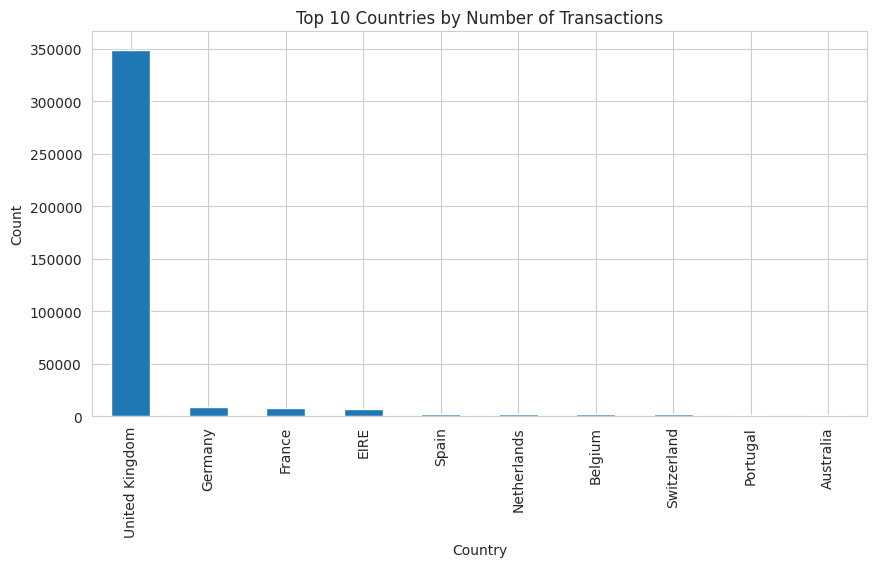

In [ ]:
plt.figure(figsize=(10,5))
data['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

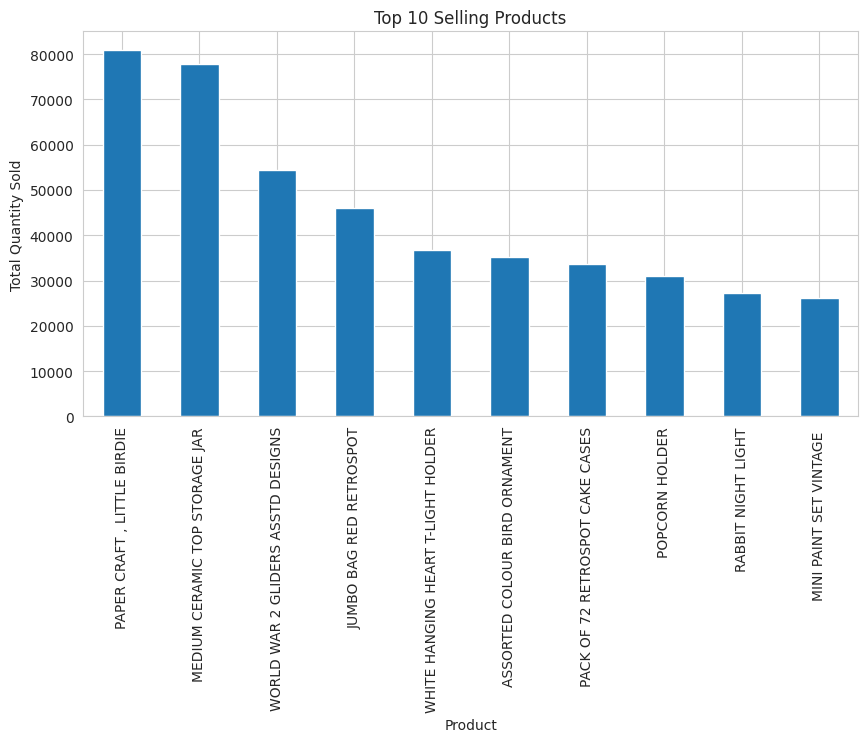

In [ ]:
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.show()

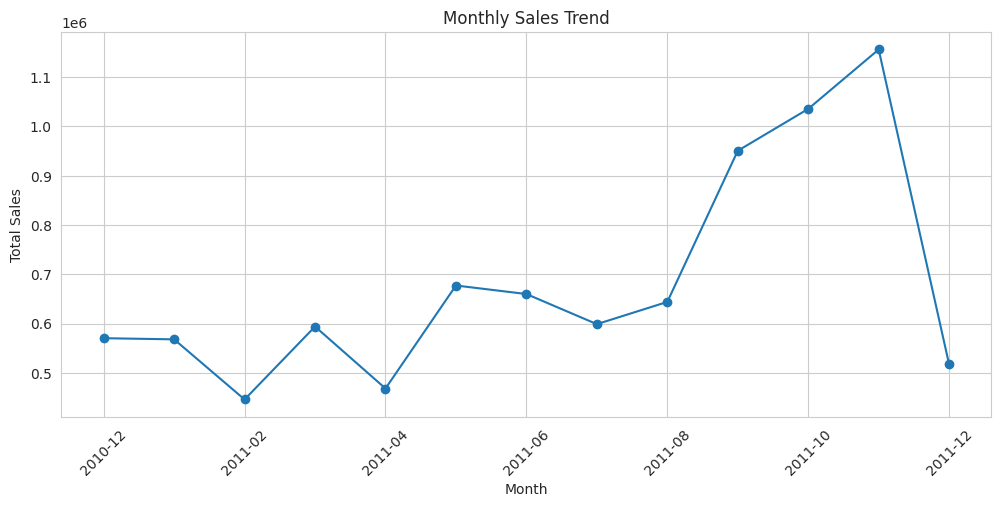

In [ ]:
data['Month'] = data['InvoiceDate'].dt.to_period('M').astype(str)

monthly_sales = data.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Snapshot date = one day after the last transaction date
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM shape:", rfm.shape)
display(rfm.head())

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [ ]:
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


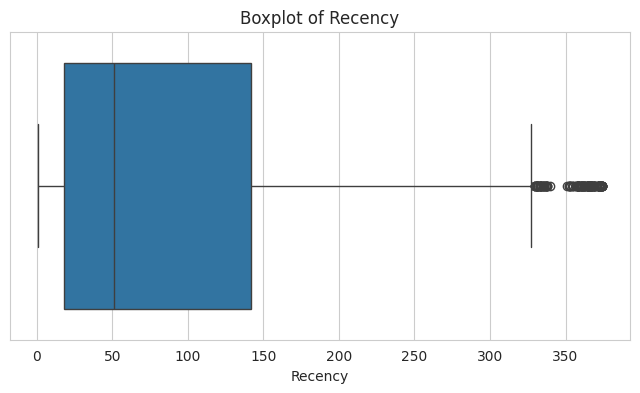

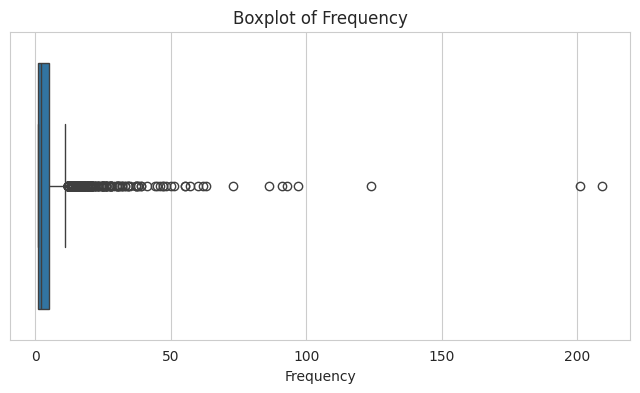

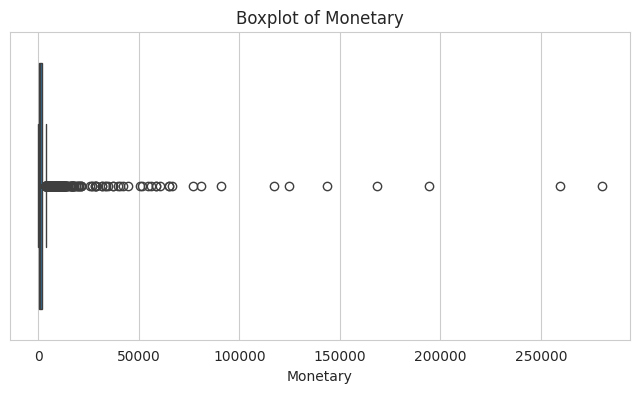

In [ ]:
for col in ['Recency', 'Frequency', 'Monetary']:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=rfm[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
rfm_out = rfm.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm_out[col].quantile(0.25)
    Q3 = rfm_out[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # cap values
    rfm_out[col] = np.where(rfm_out[col] < lower, lower, rfm_out[col])
    rfm_out[col] = np.where(rfm_out[col] > upper, upper, rfm_out[col])

display(rfm_out.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326.0,1.0,3691.77
1,12347.0,2.0,7.0,3691.77
2,12348.0,75.0,4.0,1797.24
3,12349.0,19.0,1.0,1757.55
4,12350.0,310.0,1.0,334.40


In [ ]:
rfm_features = rfm_out[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaled data shape:", rfm_scaled.shape)

Scaled data shape: (4338, 3)


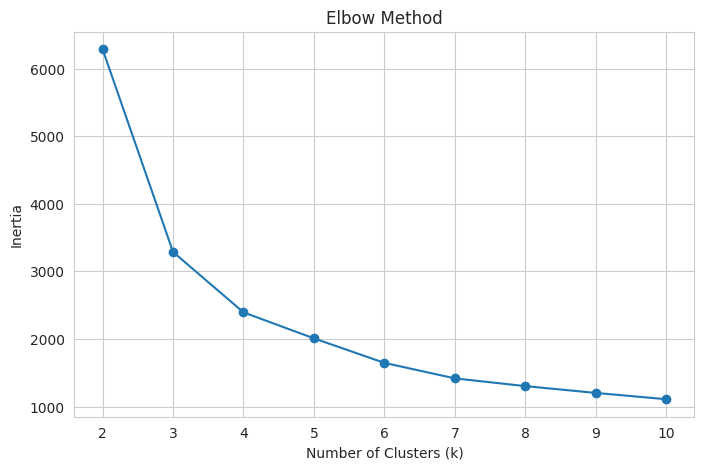

In [ ]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

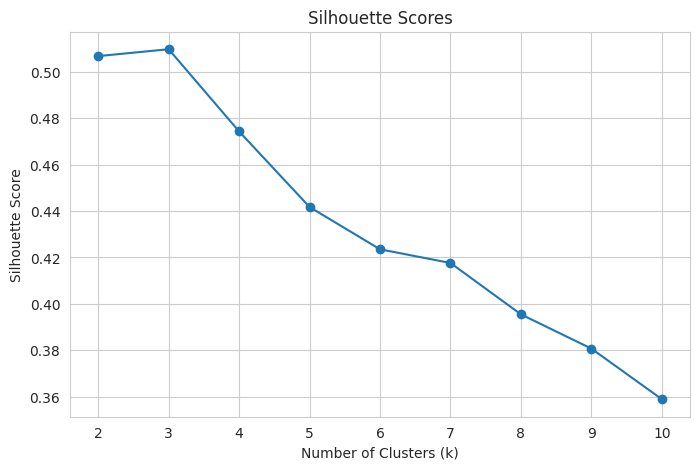

k = 2, silhouette score = 0.5067
k = 3, silhouette score = 0.5097
k = 4, silhouette score = 0.4743
k = 5, silhouette score = 0.4417
k = 6, silhouette score = 0.4235
k = 7, silhouette score = 0.4176
k = 8, silhouette score = 0.3955
k = 9, silhouette score = 0.3807
k = 10, silhouette score = 0.3589


In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}, silhouette score = {score:.4f}")

In [ ]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm_out['Cluster'] = kmeans.fit_predict(rfm_scaled)

display(rfm_out.head())

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326.0,1.0,3691.77,1
1,12347.0,2.0,7.0,3691.77,3
2,12348.0,75.0,4.0,1797.24,0
3,12349.0,19.0,1.0,1757.55,2
4,12350.0,310.0,1.0,334.40,1


In [ ]:
print("Cluster counts:")
print(rfm_out['Cluster'].value_counts())

Cluster counts:
Cluster
2    1907
1    1009
0     853
3     569
Name: count, dtype: int64


In [ ]:
cluster_summary = rfm_out.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0          39.83       5.00   1951.47
1         248.30       1.45    410.92
2          52.77       1.98    539.68
3          20.32       9.86   3373.27


In [ ]:
rfm_final = rfm.merge(rfm_out[['CustomerID', 'Cluster']], on='CustomerID', how='left')
display(rfm_final.head())

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,1
1,12347.0,2,7,4310.00,3
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,2
4,12350.0,310,1,334.40,1


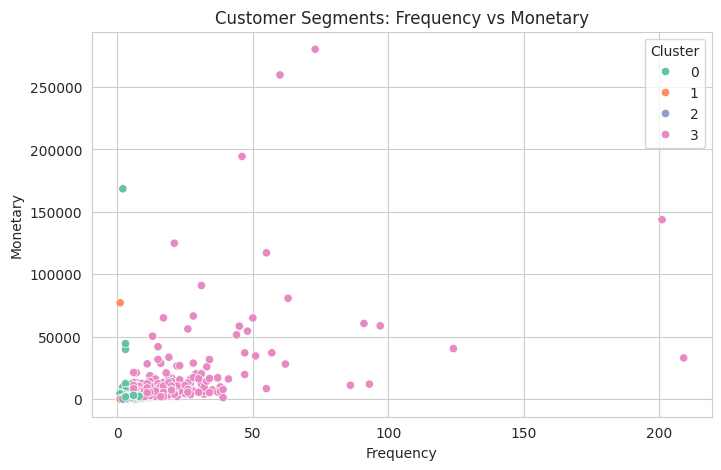

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm_final, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title("Customer Segments: Frequency vs Monetary")
plt.show()

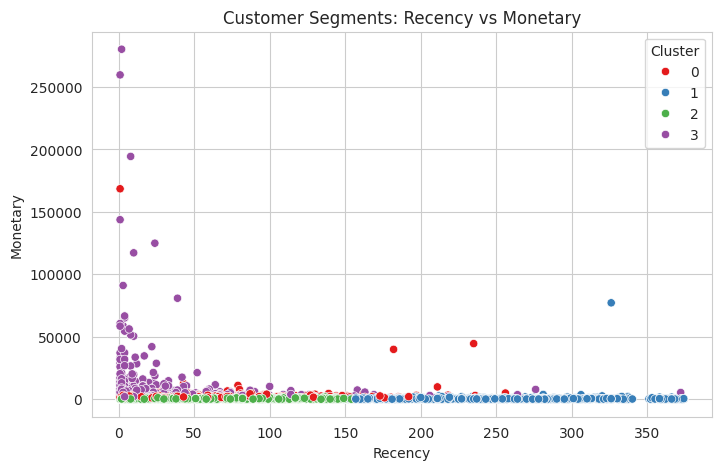

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm_final, x='Recency', y='Monetary', hue='Cluster', palette='Set1')
plt.title("Customer Segments: Recency vs Monetary")
plt.show()

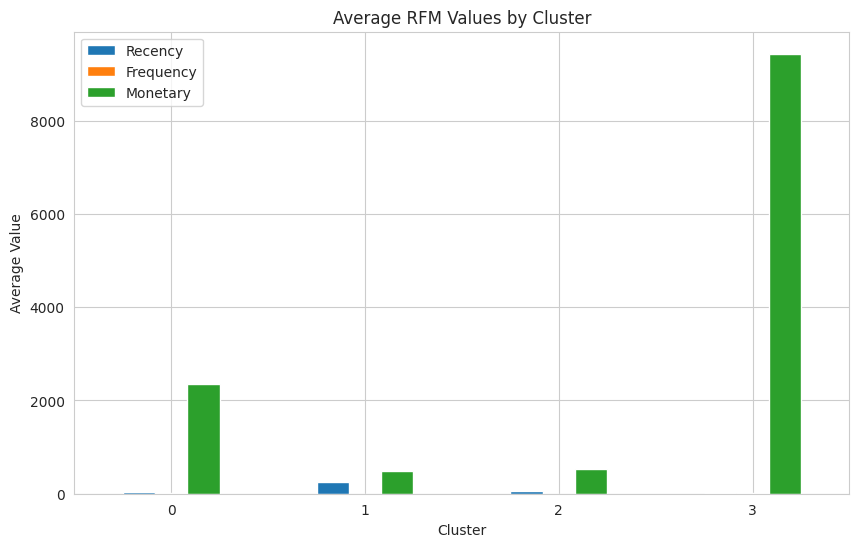

In [ ]:
cluster_summary = rfm_final.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary.plot(kind='bar', figsize=(10,6))
plt.title("Average RFM Values by Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

In [ ]:
cluster_summary = rfm_final.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0          39.83       5.00   2346.94
1         252.94       1.45    483.87
2          52.77       1.98    539.68
3          20.40      15.85   9433.86


In [ ]:
# Example only — change mapping after seeing your cluster_summary
segment_map = {
    0: 'Loyal Customers',
    1: 'Inactive Customers',
    2: 'Regular Customers',
    3: 'High Value Customers'
}

rfm_final['Segment'] = rfm_final['Cluster'].map(segment_map)
display(rfm_final.head())

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,1,Inactive Customers
1,12347.0,2,7,4310.00,3,High Value Customers
2,12348.0,75,4,1797.24,0,Loyal Customers
3,12349.0,19,1,1757.55,2,Regular Customers
4,12350.0,310,1,334.40,1,Inactive Customers


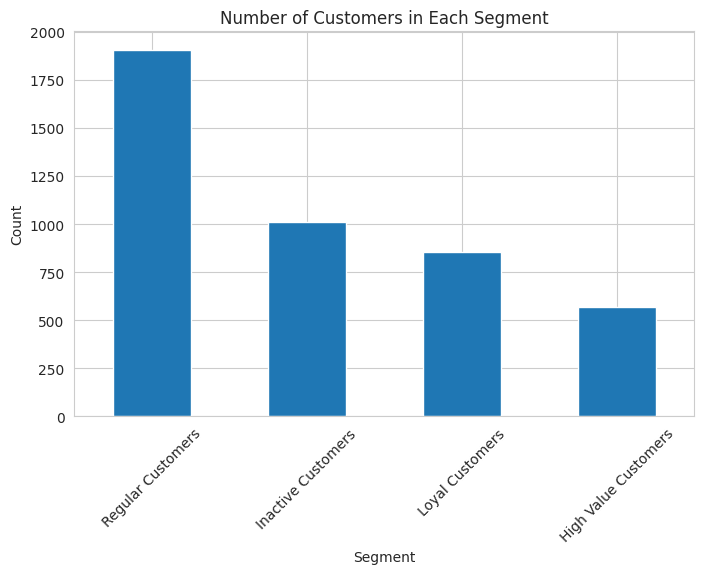

In [ ]:
plt.figure(figsize=(8,5))
rfm_final['Segment'].value_counts().plot(kind='bar')
plt.title("Number of Customers in Each Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
rfm_final.to_csv('customer_segments_output.csv', index=False)
print("Final segmented customer file saved as customer_segments_output.csv")

Final segmented customer file saved as customer_segments_output.csv


Example insights:
High-value customers ko loyalty rewards, exclusive discounts, and premium recommendations diye ja sakte hain.
Inactive customers ko win-back campaigns, coupons, and reminder emails bheje ja sakte hain.
New customers ko onboarding offers aur personalized recommendations se retain kiya ja sakta hai.
Regular customers ko upsell/cross-sell campaigns target kiye ja sakte hain.
RFM segmentation se marketing budget ko zyada effectively allocate kiya ja sakta hai.

In [1]:
print("Project Completed Successfully!")
print("Model Used: KMeans Clustering")
print("Features Used: Recency, Frequency, Monetary (RFM)")
print("Objective: Segment customers based on purchase behavior")

Project Completed Successfully!
Model Used: KMeans Clustering
Features Used: Recency, Frequency, Monetary (RFM)
Objective: Segment customers based on purchase behavior
